# Python Exception Handling



## Learning Goals

By the end of this notebook, you should be able to:
- Explain what exceptions are and why handling them matters.
- Use `try`, `except`, `else`, and `finally` correctly.
- Handle multiple exception types in clean ways.
- Use `raise` to trigger exceptions intentionally.
- Create and use custom exceptions.

## 1. Exception vs Error

- **Error**: Usually indicates a problem in program structure or syntax (for example, `SyntaxError`).
- **Exception**: Runtime issue that can be handled (for example, invalid input, missing file, divide by zero).

### Why exceptions are important
- Prevent sudden program crashes.
- Improve user experience by showing meaningful messages.
- Help with debugging and recovery logic.

## 2. Core Syntax Pattern

```python
try:
    # risky code
except SpecificError:
    # handle known error
else:
    # runs only when no exception occurs
finally:
    # always runs (cleanup)
```

Notes:
- `else` and `finally` are optional.
- You can have multiple `except` blocks.
- Prefer catching specific exceptions over broad `Exception`.



```text
try:
    risky code
except SpecificError:
    handle known issue
except AnotherError:
    handle another issue
else:
    run only if no exception
finally:
    always runs (cleanup)
```


In [4]:
# Basic try-except-else-finally example
numerator = 10
denominator = 2

try:
    result = numerator / denominator
except ZeroDivisionError:
    print("Cannot divide by zero.")
else:
    print("Division successful. Result:", result)
finally:
    print("Execution completed.")

Division successful. Result: 5.0
Execution completed.


## 3. Common Built-in Exceptions

Frequently seen exceptions:
- `ZeroDivisionError`
- `ValueError`
- `TypeError`
- `FileNotFoundError`
- `IndexError`
- `KeyError`

## Python Exception Hierarchy 

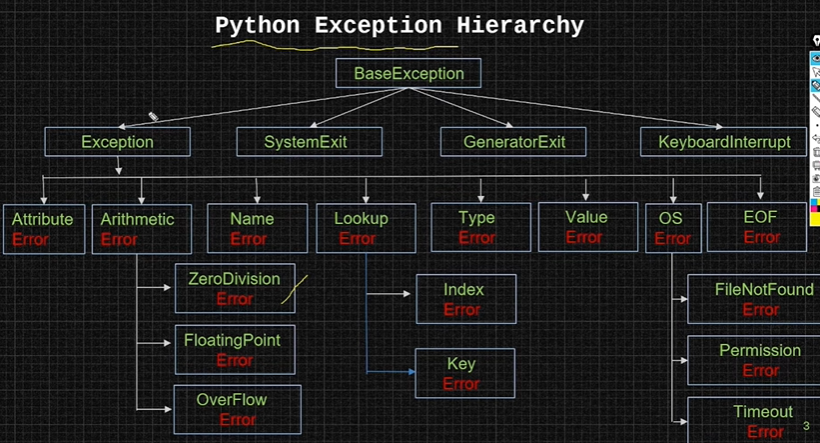

Interview note:
- Most application-level handling should catch subclasses of `Exception`.
- Avoid catching `BaseException` in normal business code.

In [5]:
# ZeroDivisionError example with reusable function
def safe_divide(a, b):
    try:
        return a / b
    except ZeroDivisionError:
        return "Error: denominator cannot be zero."

print(safe_divide(10, 2))
print(safe_divide(10, 0))

5.0
Error: denominator cannot be zero.


In [6]:
# ValueError example
def add_with_conversion(x, y_text):
    try:
        return x + int(y_text)
    except ValueError:
        print("Error: y_text must contain a valid integer string.")

print(add_with_conversion(100, "25"))
print(add_with_conversion(100, "abc"))

125
Error: y_text must contain a valid integer string.
None


## 4. Handling Multiple Exceptions

Use different `except` blocks when each exception needs a separate message.
Use tuple style when one handling path is enough.

In [7]:
# Method 1: separate except blocks
values = [1, 2, 3]
idx = 5
text_number = "xyz"

try:
    print("Value at index:", values[idx])
    print("Sum:", values[0] + int(text_number))
except IndexError:
    print("IndexError: invalid index for list.")
except ValueError:
    print("ValueError: cannot convert text_number to int.")
finally:
    print("Done with method 1.")

IndexError: invalid index for list.
Done with method 1.


In [8]:
# Method 2: tuple style except
values = [1, 2, 3]
idx = 5
text_number = "20"

try:
    print("Value at index:", values[idx])
    print("Sum:", values[0] + int(text_number))
except (IndexError, ValueError) as exc:
    print(f"Handled error: {exc}")
finally:
    print("Done with method 2.")

Handled error: list index out of range
Done with method 2.


## 5. Generic Exception Handling (Use Carefully)

Catching `Exception` is useful for fallback handling, logging, or cleanup.
Avoid hiding real bugs silently.

In [10]:
# Generic catch example
try:
    data = [1, 2, 3]
    print(data[10])
except Exception as e:
    print("An unexpected error occurred.")
    print("Exception type:", type(e).__name__)  # Print the type of the exception
    print("Exception message:", str(e))         # Print the exception message for more details

An unexpected error occurred.
Exception type: IndexError
Exception message: list index out of range


## 6. Using `raise`

Use `raise` when a condition violates a business rule and you want to stop normal flow with a clear error.

In [12]:
def categorize_age(age):
    if age < 0:
        raise ValueError("Age cannot be negative.")
    if age < 18:
        return "Minor"
    return "Adult"

for age in [15, -5, 25]:
    try:
        print(f"Age {age}: {categorize_age(age)}")
    except ValueError as e:
        print(f"Age {age}: {e}")

Age 15: Minor
Age -5: Age cannot be negative.
Age 25: Adult


## 7. Custom (User-Defined) Exception

Create custom exceptions when built-in exception names do not clearly express your domain rule.

In [15]:
# Approach 1: pass message directly when raising
class FiveDivisionError(Exception):
    pass


def restricted_divide(num, denom):
    if denom == 5:
        raise FiveDivisionError("Division by 5 is not allowed.")
    return num / denom

try:
    print(restricted_divide(10, 5))
except FiveDivisionError as exc:
    print("Custom exception:", exc)

Custom exception: Division by 5 is not allowed.


### Approach 2: Set the default message inside custom exception class

In this style, the class itself defines the message, so raising the exception stays short and clean.

In [16]:
# Approach 2: keep default message inside exception class
class FiveDivisionErrorV2(Exception):
    def __init__(self, message="Division by 5 is not allowed."):
        super().__init__(message)


def restricted_divide_v2(num, denom):
    if denom == 5:
        raise FiveDivisionErrorV2()
    return num / denom

try:
    print(restricted_divide_v2(10, 5))
except FiveDivisionErrorV2 as exc:
    print("Custom exception:", exc)

Custom exception: Division by 5 is not allowed.


## 8. Best Practices (Interview + Real Projects)

- Catch the most specific exception possible.
- Keep `try` blocks small and focused.
- Use `finally` for cleanup (closing files, releasing resources).
- Avoid silent exception handling (`except: pass`).
- Log exception details in production systems.
- Use custom exceptions to express domain-specific rules clearly.

## 9. Quick Revision Checklist

Before interviews or coding tests, revise these:
- Difference between `Error` and `Exception`.
- When `else` and `finally` execute.
- Multiple `except` styles.
- Why and when to use `raise`.
- How and why to define custom exceptions.

## 10. Interview Strategy (How to Answer)

Use this simple answer flow in interviews:
1. Define the exception briefly.
2. Explain why it happens.
3. Show one clean handling example.
4. Mention one best practice.

Example speaking line:
"A ValueError occurs when a function gets a valid type but invalid value. I handle it with try-except and return a user-friendly message. I also avoid broad except unless I log and re-raise when needed."

## 11. Most Asked Interview Questions (Quick Q&A)

1. Q: What is exception handling?

   A: It handles runtime errors gracefully so the program does not crash unexpectedly.

2. Q: Error vs Exception?

   A: Errors are mostly code/syntax issues; exceptions are runtime issues that can often be handled.

3. Q: `except Exception` vs bare `except`?

   A: `except Exception` is safer. Bare `except` catches almost everything and is usually avoided.

4. Q: When does `else` run?

   A: Only when `try` runs without any exception.

5. Q: When does `finally` run?

   A: Always, whether exception happens or not.

6. Q: Why use multiple `except` blocks?

   A: To handle different exceptions with different messages/actions.

7. Q: Why use `raise`?

   A: To throw a clear, intentional exception for invalid business conditions.

8. Q: Why create custom exceptions?

   A: To express domain-specific errors clearly.

9. Q: Best practices?

   A: Catch specific exceptions, keep `try` blocks small, and avoid silent `except: pass`.

10. Q: Should exceptions be used for normal control flow?

    A: No. They are slower and should be used for exceptional cases only.

In [ ]:
# Interview pattern 1: input validation with clear exception design

def parse_positive_int(text):
    """Convert text to positive int or raise a clear error."""
    try:
        value = int(text)
    except ValueError as exc:
        raise ValueError("Input must be an integer.") from exc

    if value <= 0:
        raise ValueError("Input must be greater than zero.")

    return value

for sample in ["42", "-3", "abc"]:
    try:
        print(f"Input {sample!r} ->", parse_positive_int(sample))
    except ValueError as exc:
        print(f"Input {sample!r} -> {exc}")

In [ ]:
# Interview pattern 2: file handling with try-except-else-finally

def read_first_line(path):
    file_obj = None
    try:
        file_obj = open(path, "r", encoding="utf-8")
        first_line = file_obj.readline().strip()
    except FileNotFoundError:
        return "File not found."
    except PermissionError:
        return "Permission denied while opening file."
    else:
        return f"First line: {first_line}"
    finally:
        if file_obj is not None:
            file_obj.close()

print(read_first_line("data.txt"))
print(read_first_line("missing_file.txt"))

## 12. 2-Minute Final Revision Card

If you remember only this, you can still answer most interview questions:
- try: put risky code only.
- except SpecificError: handle expected failures.
- else: executes only when try succeeds.
- finally: executes always, best for cleanup.
- raise: throw explicit exceptions for invalid business conditions.
- Custom exception: improves readability for domain-specific rules.

Common mistakes to avoid:
- Writing very large try blocks.
- Using bare except.
- Swallowing errors with except: pass.
- Returning vague error messages.

